In [36]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [37]:
df = pd.read_csv("../data/diabetes.csv")

print(df.shape)

df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [38]:
batch_size = len(df) // 10

batches = []

for i in range(10):

    start = i * batch_size

    if i == 9:
        batch = df.iloc[start:]

    else:
        batch = df.iloc[start:start + batch_size]

    batches.append(batch)

print("Number of batches:", len(batches))

Number of batches: 10


In [39]:
results = []

In [40]:
for i in range(3, 8):

    print(f"Processing Window {i}")

    # Previous 3 batches
    window = pd.concat([
        batches[i-3],
        batches[i-2],
        batches[i-1]
    ])

    # Future batch
    future_batch = batches[i+1]

    # Rolling statistics
    rolling_mean = window.mean(numeric_only=True)

    rolling_std = window.std(numeric_only=True)

    trend = (
        batches[i-1].mean(numeric_only=True)
        -
        batches[i-3].mean(numeric_only=True)
    )

    X_train = window.drop(
        "Outcome",
        axis=1
    )

    y_train = window["Outcome"]

    X_future = future_batch.drop(
        "Outcome",
        axis=1
    )

    y_future = future_batch["Outcome"]

    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_future = scaler.transform(
        X_future
    )

    model = tf.keras.Sequential([

        tf.keras.layers.Dense(
            64,
            activation="relu",
            input_shape=(X_train.shape[1],)
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )

    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    y_prob = model.predict(
        X_future,
        verbose=0
    )

    thresholds = [
        0.3,
        0.4,
        0.5,
        0.6,
        0.7
    ]

    best_f1 = 0

    best_threshold = 0.5

    for threshold in thresholds:

        y_pred = (
            y_prob > threshold
        ).astype(int)

        current_f1 = f1_score(
            y_future,
            y_pred,
            zero_division=0
        )

        if current_f1 > best_f1:

            best_f1 = current_f1

            best_threshold = threshold

    y_pred = (
        y_prob > best_threshold
    ).astype(int)

    acc = accuracy_score(
        y_future,
        y_pred
    )

    precision = precision_score(
        y_future,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_future,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_future,
        y_pred,
        zero_division=0
    )

    results.append([

        i,

        acc,

        precision,

        recall,

        f1,

        best_threshold

    ])

Processing Window 3


/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Window 4


/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Window 5


/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Window 6


/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing Window 7


/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Window",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "Threshold"

    ]

)

results_df

,Window,Accuracy,Precision,Recall,F1,Threshold
0,3,0.710526,0.578947,0.785714,0.666667,0.4
1,4,0.657895,0.531915,0.862069,0.657895,0.3
2,5,0.763158,0.400000,0.571429,0.470588,0.5
3,6,0.671053,0.466667,0.608696,0.528302,0.4
4,7,0.605263,0.448980,0.880000,0.594595,0.3


In [42]:
print(len(results_df))

5


In [43]:
os.makedirs(
    "../results/week5",
    exist_ok=True
)

In [44]:
results_df.to_csv(

    "../results/week5/proactive_results.csv",

    index=False

)

print("CSV Saved")

CSV Saved


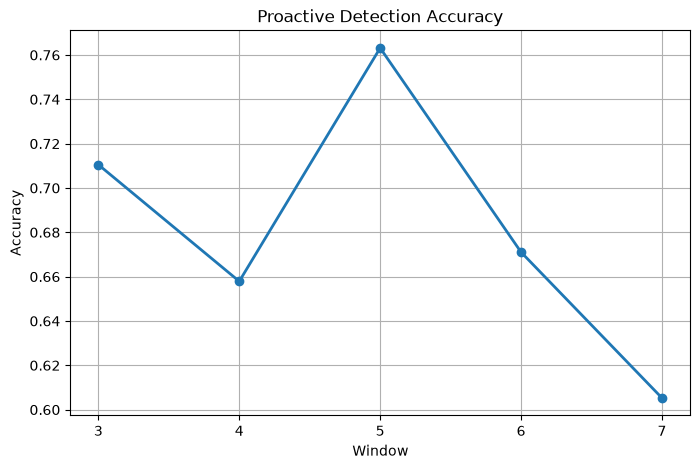

In [45]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(
    results_df["Window"]
)

plt.grid(True)

plt.title(
    "Proactive Detection Accuracy"
)

plt.xlabel(
    "Window"
)

plt.ylabel(
    "Accuracy"
)

plt.savefig(
    "../results/week5/proactive_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

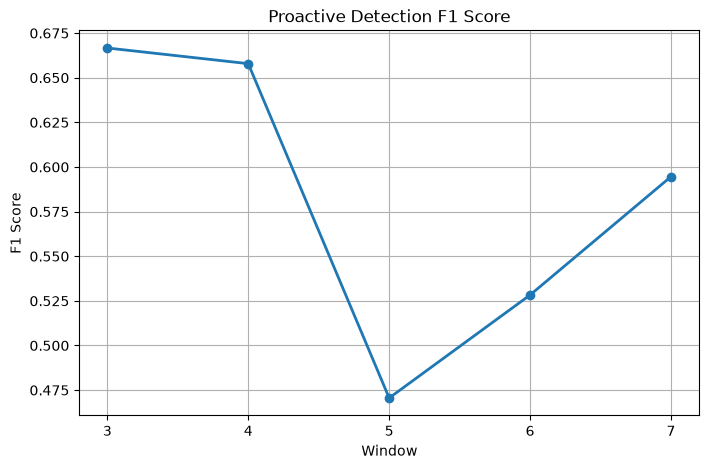

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["F1"],
    marker="o",
    linewidth=2
)

plt.xticks(
    results_df["Window"]
)

plt.grid(True)

plt.title(
    "Proactive Detection F1 Score"
)

plt.xlabel(
    "Window"
)

plt.ylabel(
    "F1 Score"
)

plt.savefig(
    "../results/week5/proactive_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
print(results_df)

   Window  Accuracy  Precision    Recall        F1  Threshold
0       3  0.710526   0.578947  0.785714  0.666667        0.4
1       4  0.657895   0.531915  0.862069  0.657895        0.3
2       5  0.763158   0.400000  0.571429  0.470588        0.5
3       6  0.671053   0.466667  0.608696  0.528302        0.4
4       7  0.605263   0.448980  0.880000  0.594595        0.3
